In [5]:
# 6 strategies, used StraightForceToColony to see if results are different

# adding ApplyColonyPullingForce() to informed as 5 but more runs

In [6]:
from sim_tools import run_simulation, SimulationParameters
import matplotlib.pyplot as plt
import numpy as np
import random
from tqdm import tqdm

In [7]:
num_sim = 10
steering_strategies = 6

use_pher = [i for i in range(steering_strategies*num_sim)]

batch_results2 = [(run_simulation(SimulationParameters(usePheromoneSteering=pher % steering_strategies), headless=True), pher % steering_strategies)
                 for pher in tqdm(use_pher)]

100%|██████████| 60/60 [09:58<00:00,  9.97s/it]


In [8]:
Steering_names = [
    "home",
    "circle",
    "gradient",
    "gaussian",
    "Inverse Square",
    "Exponential",
]

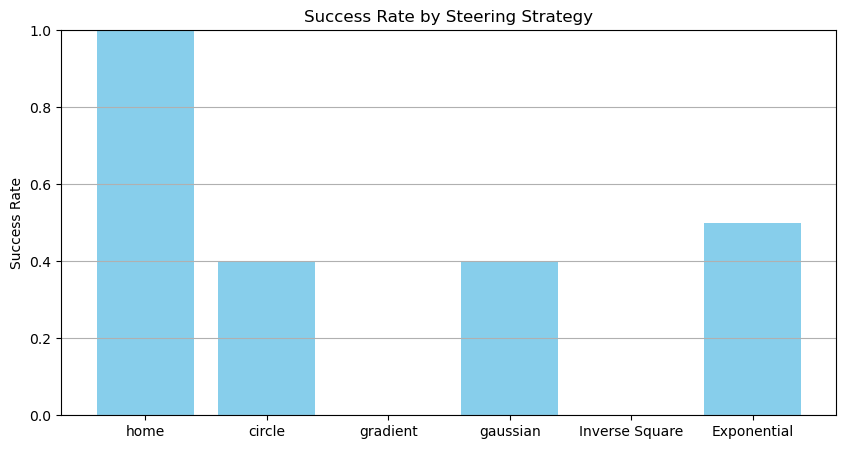

home: Success Rate=100.00% (10/10)
circle: Success Rate=40.00% (4/10)
gradient: Success Rate=0.00% (0/10)
gaussian: Success Rate=40.00% (4/10)
Inverse Square: Success Rate=0.00% (0/10)
Exponential: Success Rate=50.00% (5/10)


In [9]:
def plot_success_rates(batch_results, num_strategies=6, strategy_names=None):
    # Count successes for each strategy
    success_counts = [0] * num_strategies
    total_counts = [0] * num_strategies

    for res, strategy in batch_results:
        if 0 <= strategy < num_strategies:
            total_counts[strategy] += 1
            if res and getattr(res, "didSucceed", False):
                success_counts[strategy] += 1

    # Calculate success rates
    success_rates = [
        (success_counts[i] / total_counts[i]) if total_counts[i] else 0
        for i in range(num_strategies)
    ]

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(num_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(num_strategies)]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(range(num_strategies), success_rates,
            tick_label=labels, color='skyblue')
    plt.ylabel("Success Rate")
    plt.title("Success Rate by Steering Strategy")
    plt.ylim(0, 1)
    plt.grid(axis='y')
    plt.show()

    # Print summary
    for i in range(num_strategies):
        print(
            f"{labels[i]}: Success Rate={success_rates[i]:.2%} ({success_counts[i]}/{total_counts[i]})")


plot_success_rates(batch_results2, steering_strategies, Steering_names)

In [10]:
# print results
def print_results(batch_results):
    for res, ss in batch_results:
        if res:
            print(
                f"Run (usePheromoneSteering={ss}): Success, duration={res.duration}, success={res.didSucceed}")
        else:
            print(f"Run (usePheromoneSteering={ss}): Failed")                      

In [11]:
print_results(batch_results2)

Run (usePheromoneSteering=0): Success, duration=171.68504333496094, success=True
Run (usePheromoneSteering=1): Success, duration=258.3309631347656, success=True
Run (usePheromoneSteering=2): Success, duration=600.0375366210938, success=False
Run (usePheromoneSteering=3): Success, duration=600.1403198242188, success=False
Run (usePheromoneSteering=4): Success, duration=600.0101928710938, success=False
Run (usePheromoneSteering=5): Success, duration=207.3770751953125, success=True
Run (usePheromoneSteering=0): Success, duration=196.02142333984375, success=True
Run (usePheromoneSteering=1): Success, duration=239.14195251464844, success=True
Run (usePheromoneSteering=2): Success, duration=600.0404052734375, success=False
Run (usePheromoneSteering=3): Success, duration=600.0031127929688, success=False
Run (usePheromoneSteering=4): Success, duration=600.0299682617188, success=False
Run (usePheromoneSteering=5): Success, duration=281.5749206542969, success=True
Run (usePheromoneSteering=0): S

In [12]:
import matplotlib.pyplot as plt


def plot_torus_positions_by_strategy(batch_results, strategy_names=None):
    """
    Plots the torus positions for each strategy in separate graphs.
    Each plot shows the paths for all successful runs of that strategy.
    """
    num_strategies = max(pher for _, pher in batch_results) + 1
    if strategy_names is None:
        strategy_names = [f"Steering={i}" for i in range(num_strategies)]

    for strategy in range(num_strategies):
        # Collect all successful torus positions for this strategy
        paths = [
            res.torusPositions for res, pher in batch_results
            if pher == strategy and res and hasattr(res, "torusPositions") and res.didSucceed
        ]
        if not paths:
            continue  # Skip if no successful runs

        plt.figure(figsize=(6, 6))
        for path in paths:
            xs = [p.x for p in path]
            ys = [p.y for p in path]
            plt.plot(xs, ys, alpha=0.5)
        plt.title(f"Torus Paths - {strategy_names[strategy]}")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.grid(True)
        plt.axis("equal")
        plt.show()

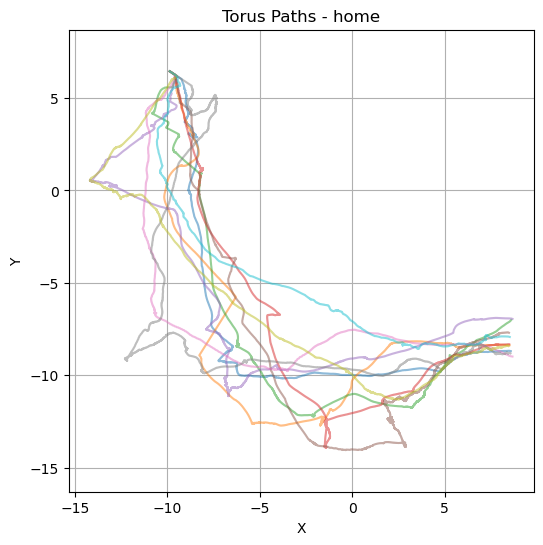

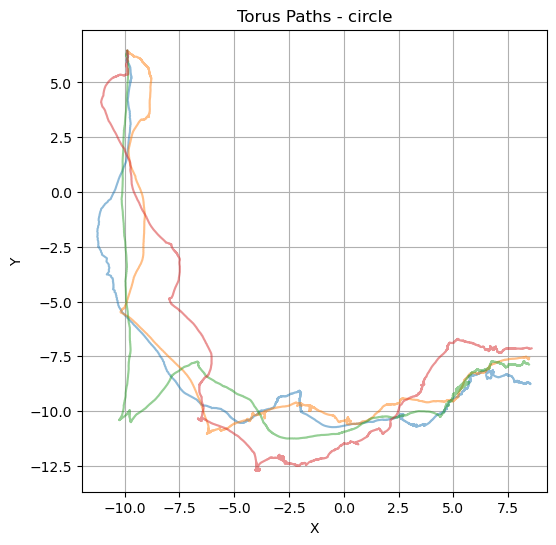

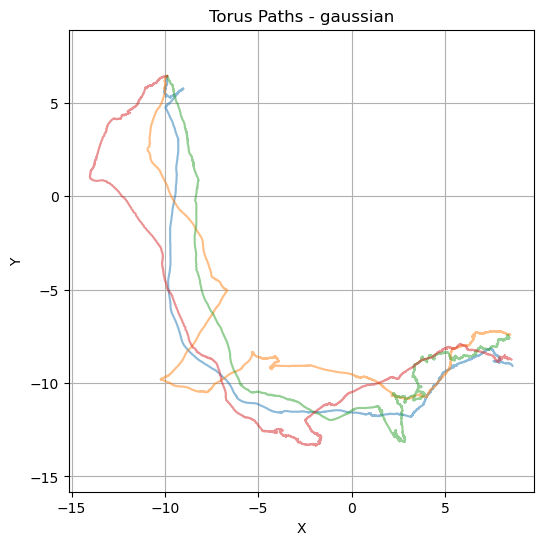

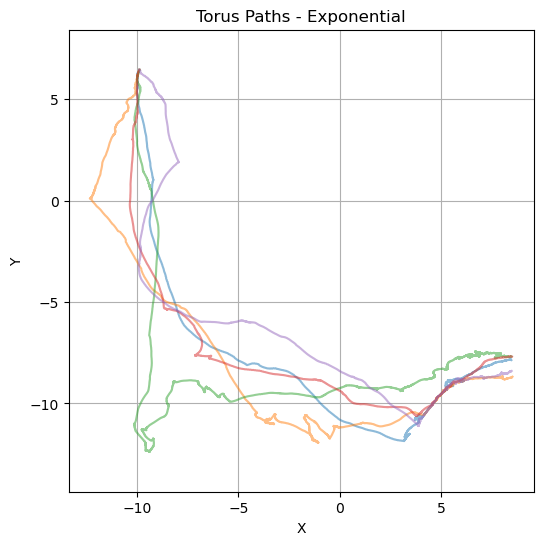

In [13]:
plot_torus_positions_by_strategy(batch_results2, Steering_names)

In [14]:
import matplotlib.pyplot as plt
import numpy as np


def plot_duration_comparison(batch_results, strategy_names=None):
    """
    Plots a boxplot comparing the durations (time to win) for each strategy.
    Only successful runs are included.
    """
    # Determine number of strategies
    num_strategies = max(pher for _, pher in batch_results) + 1

    # Collect durations for each strategy
    durations_by_strategy = [[] for _ in range(num_strategies)]
    for res, strategy in batch_results:
        if res and getattr(res, "didSucceed", False):
            durations_by_strategy[strategy].append(res.duration)

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(num_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(num_strategies)]

    # Plot boxplot
    plt.figure(figsize=(10, 6))
    plt.boxplot(durations_by_strategy, tick_labels=labels)
    plt.ylabel("Duration (seconds)")
    plt.title("Time to Win by Strategy (Successful Runs Only)")
    plt.grid(True)
    plt.show()

    # Print average duration for each strategy
    for i in range(num_strategies):
        avg = np.mean(
            durations_by_strategy[i]) if durations_by_strategy[i] else float('nan')
        print(f"{labels[i]}: Average Duration = {avg:.2f} seconds")

# Example usage:

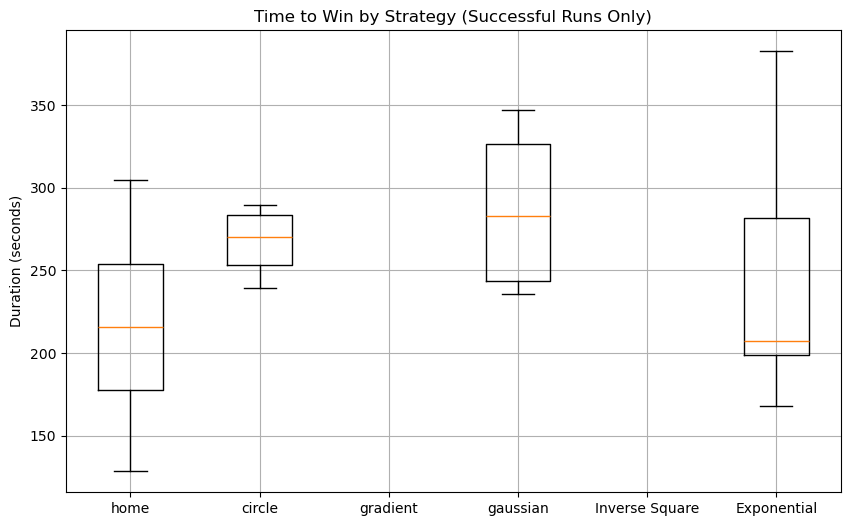

home: Average Duration = 215.35 seconds
circle: Average Duration = 267.15 seconds
gradient: Average Duration = nan seconds
gaussian: Average Duration = 287.08 seconds
Inverse Square: Average Duration = nan seconds
Exponential: Average Duration = 247.65 seconds


In [15]:
plot_duration_comparison(batch_results2, Steering_names)